In [1]:
import pandas as pd
import numpy as np
import pickle
import os

import shap
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
import warnings
warnings.filterwarnings("ignore")


In [3]:
train = pd.read_csv('/kaggle/input/train-cleaned-tg-posts/train_cleaned.csv')
test  = pd.read_csv('/kaggle/input/val-tg-lemmatised/val_lemmatized.csv')

train = train.dropna(subset=['message_lemmatized', 'label'])
test  = test.dropna(subset=['message_lemmatized', 'label'])

print(train.shape, test.shape)

vectorizer = TfidfVectorizer(
    ngram_range=(1,1),         # UNIGRAM ONLY for SHAP clarity
    max_features=25000,
    lowercase=True
)

X_train = vectorizer.fit_transform(train['message_lemmatized'])
X_test  = vectorizer.transform(test['message_lemmatized'])

y_train = train['label'].values
y_test  = test['label'].values


print("TF-IDF shape:", X_train.shape)
clf = LogisticRegression(
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    multi_class='multinomial',
    random_state=42
)

clf.fit(X_train, y_train)

print("Model trained.")


(30637, 9) (10225, 7)


In [4]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,1),         # UNIGRAM ONLY for SHAP clarity
    max_features=25000,
    lowercase=True
)

X_train = vectorizer.fit_transform(train['message_lemmatized'])
X_test  = vectorizer.transform(test['message_lemmatized'])

y_train = train['label'].values
y_test  = test['label'].values

print("TF-IDF shape:", X_train.shape)


TF-IDF shape: (30637, 25000)


Model trained.


In [6]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-macro:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred, 
    target_names=['Misinformation','Propaganda','Opposition']
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7147188264058679
F1-macro: 0.7142029619939853

Classification Report:

                precision    recall  f1-score   support

Misinformation       0.72      0.78      0.75      3502
    Propaganda       0.66      0.64      0.65      3384
    Opposition       0.78      0.72      0.75      3339

      accuracy                           0.71     10225
     macro avg       0.72      0.71      0.71     10225
  weighted avg       0.72      0.71      0.71     10225

Confusion matrix:
[[2733  541  228]
 [ 746 2180  458]
 [ 338  606 2395]]


In [7]:
explainer = shap.LinearExplainer(
    clf,
    X_train,
    feature_dependence="independent"
)


In [8]:
shap_values = explainer.shap_values(X_test)


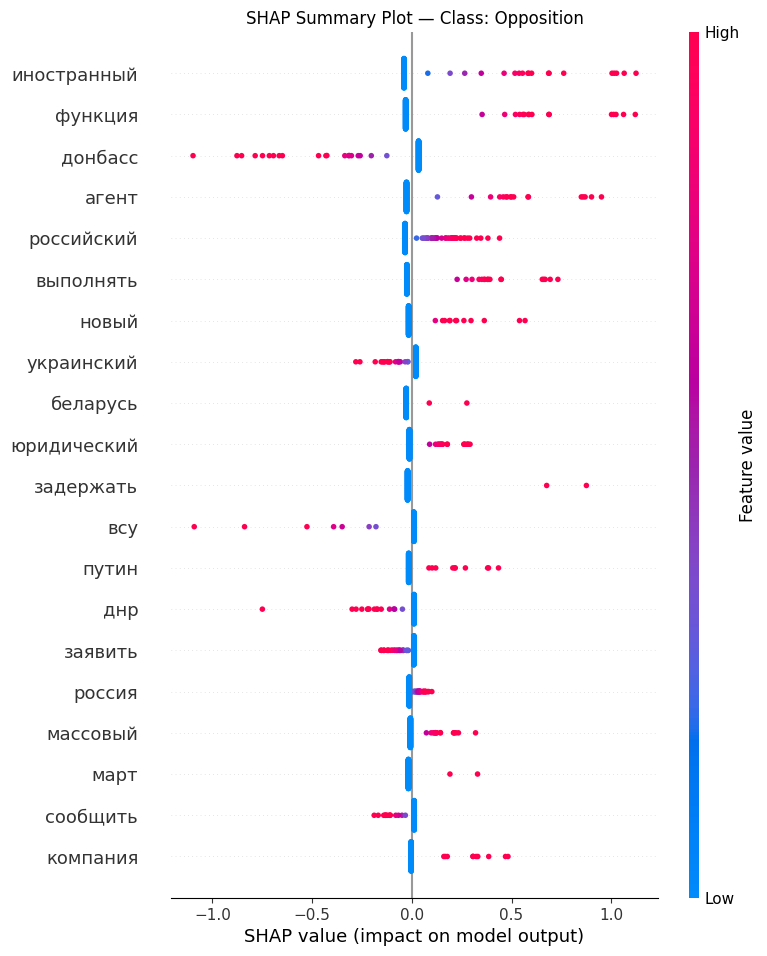

In [15]:
N = 200  # avoids memory explosion
X_dense = X_test[:N].toarray()

shap.summary_plot(
    shap_values[2][:N], 
    X_dense, 
    feature_names=vectorizer.get_feature_names_out(),
    show=False
)
plt.title("SHAP Summary Plot — Class: Opposition")
plt.show()


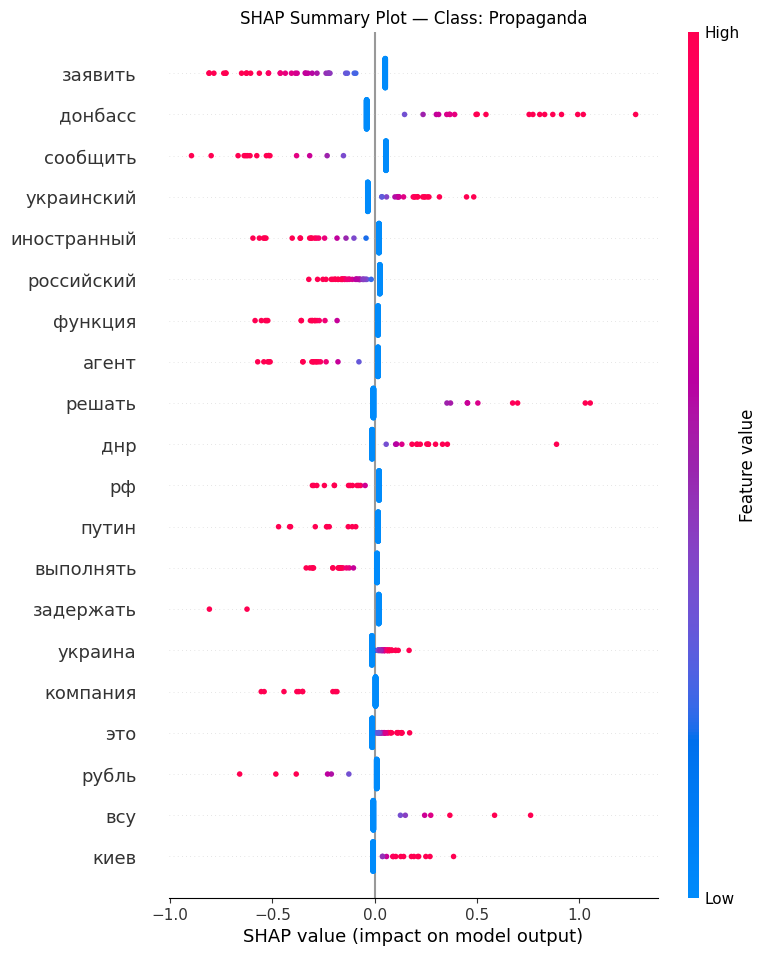

In [16]:
N = 200  # avoids memory explosion
X_dense = X_test[:N].toarray()

shap.summary_plot(
    shap_values[0][:N], 
    X_dense, 
    feature_names=vectorizer.get_feature_names_out(),
    show=False
)
plt.title("SHAP Summary Plot — Class: Propaganda")
plt.show()


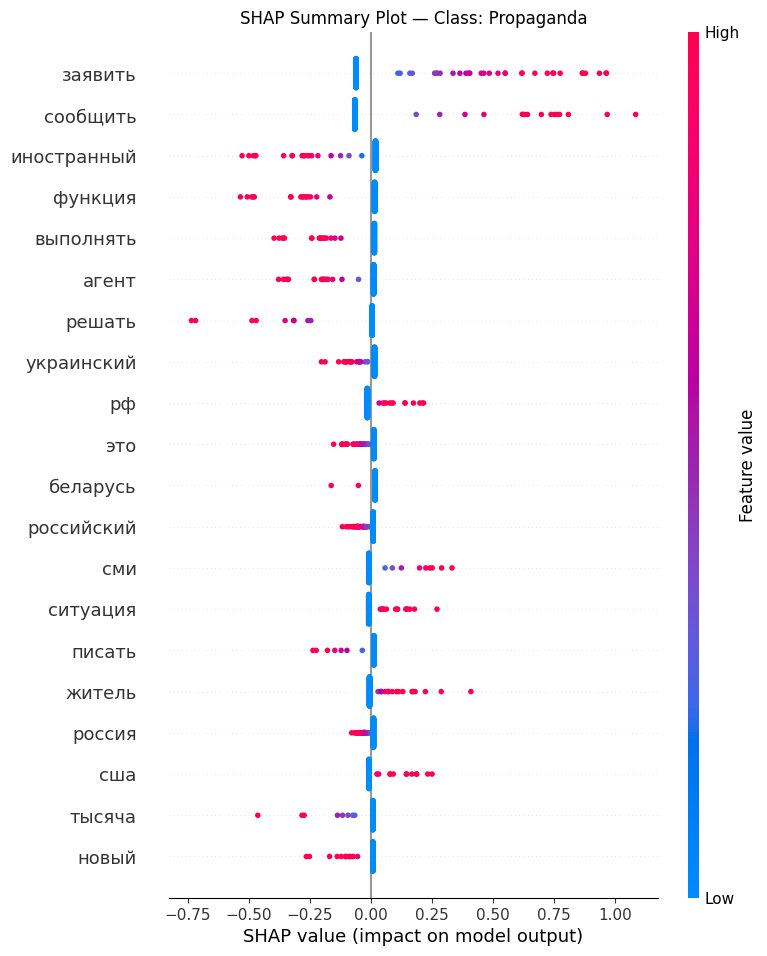

In [17]:
N = 200  # avoids memory explosion
X_dense = X_test[:N].toarray()

shap.summary_plot(
    shap_values[1][:N], 
    X_dense, 
    feature_names=vectorizer.get_feature_names_out(),
    show=False
)
plt.title("SHAP Summary Plot — Class: Misinfo")
plt.show()


In [10]:
feature_names = np.array(vectorizer.get_feature_names_out())

for cls in range(3):
    print(f"\n=== TOP FEATURES FOR CLASS {cls} ===")
    
    class_shap = shap_values[cls].mean(axis=0)
    top_idx = np.argsort(np.abs(class_shap))[-20:]
    
    for i in reversed(top_idx):
        print(f"{feature_names[i]:<20} {class_shap[i]:.4f}")



=== TOP FEATURES FOR CLASS 0 ===
донбасс              0.0275
решать               0.0184
лнр                  0.0175
агент                -0.0151
функция              -0.0148
донецк               0.0148
украинский           -0.0135
иностранный          -0.0135
днр                  0.0105
канал                0.0104
беларусь             0.0098
задержать            0.0094
млрд                 0.0090
суд                  -0.0088
сообщить             0.0088
одкб                 0.0085
мосбиржа             0.0082
приостанавливать     0.0080
коронавирус          -0.0078
задержание           0.0075

=== TOP FEATURES FOR CLASS 1 ===
беларусь             0.0142
функция              -0.0135
решать               -0.0128
иностранный          -0.0120
сообщить             -0.0107
намписать            -0.0105
агент                -0.0100
корабль              -0.0087
выполнять            -0.0083
писать               0.0073
контакт              -0.0073
считать              0.0071
коронавирус          

In [26]:
i = 500 # choose test message
shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][i],
    feature_names=feature_names
)


In [23]:
shap.initjs()


In [37]:
# Take 5 examples
sample_texts = X_train[:5]  # this is your TF-IDF sparse matrix

# Convert to dense because shap.text can't handle sparse
sample_texts_dense = sample_texts.toarray()

# Compute SHAP values
shap_values = explainer(sample_texts_dense)

# Plot
shap.plots.text(shap_values)


AttributeError: 'numpy.float64' object has no attribute 'replace'

In [29]:
pipeline = make_pipeline(vectorizer, clf)
explainer = shap.Explainer(pipeline, masker=shap.maskers.Text(tokenizer=str.split))


NameError: name 'make_pipeline' is not defined

In [39]:
import shap
import numpy as np

# 1. Define a callable for SHAP that takes raw text
def pipeline_predict(texts):
    """
    texts: list of strings
    returns: model probability for each class
    """
    X = vectorizer.transform(texts)  # TF-IDF transform
    return clf.predict_proba(X)      # probabilities for all classes

# 2. Use a SHAP text masker
masker = shap.maskers.Text()  # automatically tokenizes words

# 3. Create the explainer
explainer = shap.Explainer(pipeline_predict, masker)

# 4. Compute SHAP values for a few samples
sample_texts = train['message_lemmatized'][1000:1003].tolist()
shap_values = explainer(sample_texts)

# 5. Plot
shap.plots.text(shap_values)



In [ ]:
# Use a pipeline as a high-level helper
!pip install -U transformers
from transformers import pipeline

pipe = pipeline("text-classification", model="MariaOnyshchuk/prop_xlmroberta")
# Load model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("MariaOnyshchuk/prop_xlmroberta")
model = AutoModelForSequenceClassification.from_pretrained("MariaOnyshchuk/prop_xlmroberta")
import torch

def classify_text(text, model, tokenizer):
    inputs = tokenizer(
        text,
        max_length=512,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )
    
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
    
    return {
        "prediction": pred,
        "probabilities": probs[0].cpu().numpy()
    }

text = "россия запросила заседание совета безопасности оон  срочное обсуждение потребовалось после того  как киев при участии специалистов из великобритании предпринял попытку атаковать в бухте севастополя гражданские суда и корабли черноморского флота  которые обеспечивали безопасность  зернового коридора   украина задействовала 16 воздушных и морских беспилотников  для их движения использовался тот самый безопасный коридор  все дроны были ликвидированы  этой террористической атакой киев сорвал зерновую сделку  россия объявила  что приостанавливает участие в ней   "
result = classify_text(text, model, tokenizer)

label_names = {0: 'Propaganda', 1: 'Misinfo', 2: 'Oposition'}
print(f"Predicted: {label_names[result['prediction']]}")
print(f"Probabilities: {result['probabilities']}")